In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

import tensorflow as tf
from tensorflow.keras.layers import Input,Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras import regularizers

(1567, 590)
(1567, 2)
0
-1    1463
 1     104
Name: count, dtype: int64
0
0    1463
1     104
Name: count, dtype: int64


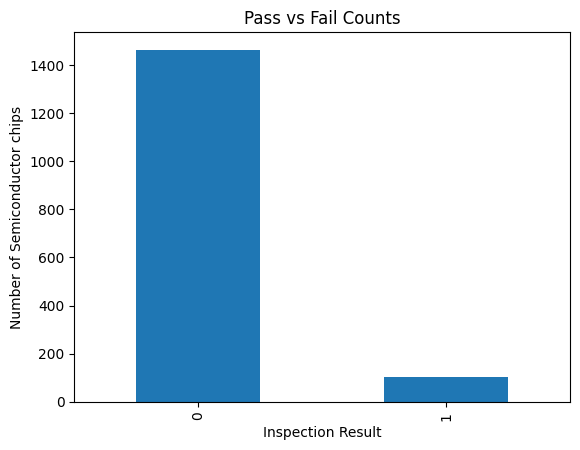

In [8]:
X= pd.read_csv("secom.data", sep= r"\s+", header=None)
labels= pd.read_csv("secom_labels.data", sep=r"\s+", header=None)
print(X.shape)
print(labels.shape)

y=labels[0]
print(y.value_counts())
y=y.replace({-1:0,1:1})
print(y.value_counts())

y.value_counts().plot(kind='bar')
plt.title('Pass vs Fail Counts')
plt.xlabel('Inspection Result')
plt.ylabel('Number of Semiconductor chips')
plt.show()

In [9]:
missing_fraction  = X.isnull().mean()
print(missing_fraction.sort_values(ascending=False).head(10))
X= X.loc[:,missing_fraction<0.5]
print(X.shape)

X= X.fillna(X.median())
print(X.isnull().sum().sum())

292    0.911934
293    0.911934
158    0.911934
157    0.911934
492    0.855775
85     0.855775
358    0.855775
220    0.855775
244    0.649649
517    0.649649
dtype: float64
(1567, 562)
0


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
lr = LogisticRegression(max_iter=1000,class_weight = 'balanced')
lr.fit(X_train_scaled, y_train)
pred_lr = lr.predict(X_test_scaled)
print(classification_report(y_test, pred_lr))

              precision    recall  f1-score   support

           0       0.94      0.88      0.91       293
           1       0.11      0.19      0.14        21

    accuracy                           0.84       314
   macro avg       0.52      0.54      0.52       314
weighted avg       0.88      0.84      0.86       314



Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.9391 - loss: 0.2612 - val_accuracy: 0.9004 - val_loss: 0.2769
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9451 - loss: 0.1275 - val_accuracy: 0.9124 - val_loss: 0.2757
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9671 - loss: 0.0734 - val_accuracy: 0.9004 - val_loss: 0.3043
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9890 - loss: 0.0427 - val_accuracy: 0.9084 - val_loss: 0.3402
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9980 - loss: 0.0207 - val_accuracy: 0.9084 - val_loss: 0.3768
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0112 - val_accuracy: 0.9084 - val_loss: 0.4320
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 1.0000 - loss: 0.0064 - val_accuracy: 0.9084 - val_loss: 0.4691
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 1.0000 - loss: 0.0041 - val_accuracy: 0.9084 - v

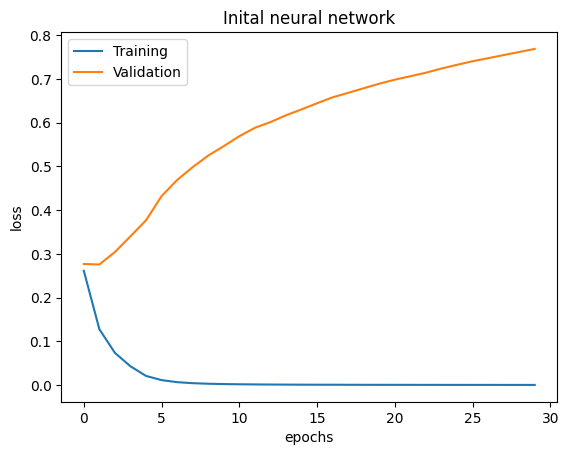

In [14]:
layer1 = Dense(128, activation='relu')
layer2 = Dense(64, activation='relu')
layer3 = Dense(1, activation='sigmoid')
NN_Model1 = Sequential([Input(shape=(X_train_scaled.shape[1],)),layer1,layer2,layer3])
NN_Model1.compile(optimizer= 'adam',loss= 'binary_crossentropy', metrics=['accuracy'])
history = NN_Model1.fit(X_train_scaled, y_train, epochs=30, batch_size=32, validation_split = 0.2)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Training','Validation'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.title('Inital neural network')
plt.show()

In [15]:
pred_prob = NN_Model1.predict(X_test_scaled)
print(pred_prob.min())
print(pred_prob.max())
print(pred_prob.mean())
pred = (pred_prob > 0.5).astype(int)
print(classification_report(y_test, pred))


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
1.1932529e-12
0.5213103
0.013386982
              precision    recall  f1-score   support

           0       0.93      1.00      0.96       293
           1       0.00      0.00      0.00        21

    accuracy                           0.93       314
   macro avg       0.47      0.50      0.48       314
weighted avg       0.87      0.93      0.90       314



Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5469 - loss: 0.8187 - val_accuracy: 0.8805 - val_loss: 0.4977
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9371 - loss: 0.3435 - val_accuracy: 0.9044 - val_loss: 0.3755
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9421 - loss: 0.2557 - val_accuracy: 0.9004 - val_loss: 0.3666
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9441 - loss: 0.2208 - val_accuracy: 0.9004 - val_loss: 0.3559
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9461 - loss: 0.1930 - val_accuracy: 0.8964 - val_loss: 0.3542
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9501 - loss: 0.1719 - val_accuracy: 0.9004 - val_loss: 0.3547
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9541 - loss: 0.1554 - val_accuracy: 0.9004 - val_loss: 0.3611
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9641 - loss: 0.1406 - val_accuracy: 0.8964 - val_loss

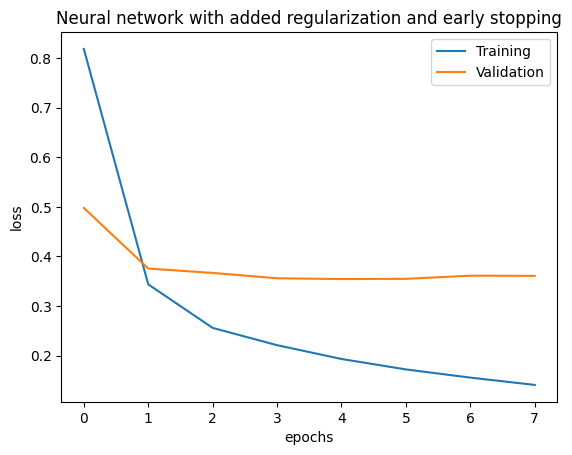

In [16]:
layer1 = Dense(32, activation='relu', kernel_regularizer = regularizers.l2(0.001))
layer2 = Dense(16, activation='relu', kernel_regularizer = regularizers.l2(0.001))
layer3 = Dense(1, activation='sigmoid')
NN_Model2 = Sequential([Input(shape=(X_train_scaled.shape[1],)),layer1,layer2,layer3])
NN_Model2.compile(optimizer= 'adam',loss= 'binary_crossentropy', metrics=['accuracy'])
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)
history = NN_Model2.fit(X_train_scaled, y_train, epochs=30, batch_size=32, validation_split = 0.2, callbacks = [early_stop])

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Neural network with added regularization and early stopping')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['Training','Validation'])
plt.show()

In [17]:
pred_prob = NN_Model2.predict(X_test_scaled)
print(pred_prob.min())
print(pred_prob.max())
print(pred_prob.mean())
print("Threshold Analysis:")
for t in [0.05, 0.1, 0.15, 0.2, 0.25]:
    pred = (pred_prob > t).astype(int)

    print("\nThreshold =", t)
    print(classification_report(y_test, pred))

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
0.000356853
0.37117293
0.057584126
Threshold Analysis:

Threshold = 0.05
              precision    recall  f1-score   support

           0       0.96      0.60      0.74       293
           1       0.10      0.62      0.17        21

    accuracy                           0.60       314
   macro avg       0.53      0.61      0.46       314
weighted avg       0.90      0.60      0.70       314


Threshold = 0.1
              precision    recall  f1-score   support

           0       0.95      0.87      0.91       293
           1       0.19      0.43      0.26        21

    accuracy                           0.84       314
   macro avg       0.57      0.65      0.58       314
weighted avg       0.90      0.84      0.87       314


Threshold = 0.15
              precision    recall  f1-score   support

           0       0.94      0.92      0.93       293
           1       0.14      0.19      0.16        21

    accuracy                      